In [1]:
%load_ext autoreload 
%autoreload 2

In [1]:
from ssa.utils import init_azure_model, init_openrouter_chat_model


In [3]:
from ssa.galeshapley import multi_galeshapley

In [ ]:
# %%
from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.agents.ssa import LLMSSA
from ssa.agents.policy import PolicyAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model, init_openrouter_chat_model
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt

# np.random.seed(13123)
# model = init_azure_model()

task_ids = [f"task_{i}" for i in range(5)]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(1)]

agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(5)]
for agent in agents:
    agent.set_policy(train_p=0.2, underbid_factor=0.9)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

market = LabourMarket(jobs=jobs, market_limit=1, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=5, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(50):
    for agent in agents:
        agent.set_policy(train_p=0.2, underbid_factor=np.random.uniform(0.8, 1))

    market.simulate_timestep()

hx = market.get_job_performance(task_id='task_a', filter_initial=True)

exp_log = market.export()

# rew = np.cumsum(exp_log.agent_reward_history, axis=1)
# plt.plot(rew.T, label=exp_log.agent_ids)
# plt.legend()


2025-09-10 13:36:39.292 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 5 agents and 5 jobs over 5 tasks. Initializing...
100%|██████████| 50/50 [00:00<00:00, 503.73it/s]


In [1]:
from langchain.schema import AIMessage, HumanMessage, SystemMessage
from langchain_core.messages import     convert_to_openai_messages

SYSTEM_PROMPT = """You are llm_1, an AI agent competing in a freelancer marketplace. Your goal is to maximize total earnings by completing jobs.\n\nGAME MECHANICS:\n- Up to 16 jobs available each round across 4 skill types: [\'SK-C\', \'SK-D\', \'SK-A\', \'SK-B\']\n- Each job lists a reference budget, but you can bid above or below this amount  \n- You can bid on up to 5 jobs per round, potentially winning multiple\n- Clients select agents considering both price and reputation for the required skill\n- Your job performance affects payment - poor performance results in partial payment\n- Skills improve through TRAINING and completing jobs\n- REPUTATION (out of 5*) is tracked per skill type, reflecting your recent job or benchmark performance from training\n- If you win no jobs after bidding, you have a chance to train in your top-choice job\'s skill\n- Game ends with 1% probability each round\n\nACTIONS (choose one per round):\n- BID: Compete for specific jobs by proposing prices. Use JOB_IDs from listings when bidding\n- TRAIN: Skip earning to improve skills in chosen skill types. Use TASK_IDs when training\n\nINFORMATION PROVIDED EACH ROUND:\n1. **MARKET ACTIVITY**: Last 10 rounds showing job_id($budget)→winner(reputation*), and current earnings rankings  \n2. **RECENT ACTIONS**: Your recent actions with outcomes, including income and reputation change\n   - Action format: "job_id@(your_bid/posted_budget|your_reputation*)→($reward|TRAIN|LOST)"\n3. **PREVIOUS REASONING**: Your reasoning from previous turn\n4. **LISTINGS**: Available jobs this round: "skill_id: job_id@budget, job_id@budget, ..."\n\nOUTPUT STRUCTURE:\n1. REASONING: Your reasoning for your actions this round\n2. ACTION: \'bid\' or \'train\'  \n3. TARGETS:\n   - If bidding: [(job_id, bid_price), ...] in preference order (max 5)\n   - If training: [skill_id, ...]\nReply in a JSON format. Do not include additional data such as in-line comments or <think> tokens. The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"description": "Data class for agent actions", "properties": {"reasoning": {"description": "Your strategic reasoning for this choice", "title": "Reasoning", "type": "string"}, "action": {"description": "Your action for this round. You can either bid for jobs (\'bid\') or train skills (\'train\')", "enum": ["bid", "train", "error"], "title": "Action", "type": "string"}, "targets": {"description": "Your preferences from highest to lowest priority. For bidding: [[job_id_1, price_1], [job_id_2, price_2], ...]. For training: [[skill_id, -1]] with only one skill.", "items": {"items": {}, "type": "array"}, "title": "Targets", "type": "array"}}, "required": ["reasoning", "action", "targets"]}\n```\n"""

ROUND_MSG = """=== ROUND 10 ===

MARKET ACTIVITY:
R1: JB-a_0($6.0)→pol_1(1.4*), JB-b_0($6.0)→pol_2(1.3*), JB-b_1($9.0)→llm_0(1.4*), JB-b_2($12.0)→llm_0(1.4*), JB-c_0($6.0)→pol_5(1.3*), JB-c_1($9.0)→pol_5(1.3*), JB-c_2($12.0)→pol_5(1.3*), JB-d_0($6.0)→pol_1(1.3*), JB-d_2($12.0)→pol_1(1.3*)
R2: JB-a_1($9.0)→pol_2(1.3*), JB-a_2($12.0)→pol_2(1.3*), JB-b_1($9.0)→llm_0(1.4*), JB-b_2($12.0)→llm_0(1.4*), JB-c_1($9.0)→pol_5(1.3*), JB-c_2($12.0)→pol_5(1.3*), JB-d_0($6.0)→llm_0(1.2*), JB-d_1($9.0)→pol_6(1.3*), JB-d_2($12.0)→pol_6(1.3*)
R3: JB-a_1($9.0)→pol_4(1.5*), JB-a_2($12.0)→pol_1(1.4*), JB-c_0($6.0)→pol_4(1.4*), JB-c_1($9.0)→pol_4(1.4*), JB-d_0($6.0)→pol_6(1.4*), JB-d_2($12.0)→pol_6(1.4*)
R4: JB-a_0($6.0)→llm_0(1.6*), JB-a_1($9.0)→pol_1(1.4*), JB-a_2($12.0)→pol_1(1.4*), JB-b_1($9.0)→llm_0(1.4*), JB-b_2($12.0)→llm_0(1.4*), JB-c_0($6.0)→pol_0(1.5*), JB-c_1($9.0)→pol_0(1.5*), JB-d_1($9.0)→llm_1(1.5*), JB-d_2($12.0)→llm_1(1.5*)
R5: JB-a_2($12.0)→llm_0(1.6*), JB-b_0($6.0)→llm_0(1.5*), JB-b_1($9.0)→llm_0(1.5*), JB-c_0($6.0)→pol_4(1.6*), JB-c_1($9.0)→pol_4(1.6*), JB-c_2($12.0)→pol_4(1.6*), JB-d_0($6.0)→llm_1(1.7*), JB-d_1($9.0)→llm_1(1.7*), JB-d_2($12.0)→llm_1(1.7*)
R6: JB-a_1($9.0)→pol_2(1.3*), JB-a_2($12.0)→pol_2(1.3*), JB-b_0($6.0)→llm_0(1.6*), JB-b_1($9.0)→llm_0(1.6*), JB-b_2($12.0)→llm_0(1.6*), JB-c_0($6.0)→pol_5(1.6*), JB-c_2($12.0)→pol_5(1.6*), JB-d_0($6.0)→llm_1(2.0*), JB-d_1($9.0)→llm_1(2.0*), JB-d_2($12.0)→llm_1(2.0*)
R7: JB-a_0($6.0)→pol_1(1.9*), JB-a_1($9.0)→pol_1(1.9*), JB-b_1($9.0)→llm_0(1.7*), JB-b_2($12.0)→llm_0(1.7*), JB-c_0($6.0)→pol_0(1.8*), JB-c_1($9.0)→pol_0(1.8*), JB-c_2($12.0)→pol_0(1.8*), JB-d_0($6.0)→llm_1(1.9*), JB-d_1($9.0)→llm_1(1.9*), JB-d_2($12.0)→llm_1(1.9*)
R8: JB-a_0($6.0)→pol_1(2.2*), JB-a_1($9.0)→pol_1(2.2*), JB-a_2($12.0)→pol_1(2.2*), JB-b_1($9.0)→llm_0(1.7*), JB-b_2($12.0)→llm_0(1.7*), JB-c_0($6.0)→pol_0(2.0*), JB-c_1($9.0)→pol_0(2.0*), JB-c_2($12.0)→pol_0(2.0*), JB-d_1($9.0)→llm_1(1.8*), JB-d_2($12.0)→llm_1(1.8*)
R9: JB-a_0($6.0)→llm_0(1.9*), JB-a_2($12.0)→pol_5(1.3*), JB-b_0($6.0)→llm_0(1.6*), JB-b_1($9.0)→llm_0(1.6*), JB-b_2($12.0)→pol_4(1.3*), JB-c_1($9.0)→pol_0(2.5*), JB-c_2($12.0)→pol_0(2.5*)

>> LEADERBOARD - #1: llm_0, $50.0 #2: pol_0, $34.2 #3: pol_1, $32.8 #4: llm_1 (YOU), $31.8 #5: pol_5, $16.4 #6: pol_4, $15.6 #7: pol_6, $10.7 #8: pol_2, $10.4 #9: pol_7, $0.0 #10: pol_3, $0.0

RECENT ACTIONS:
R1: BID JB-b_2@($10.0/12.0|1.4*)→$3.08, JB-c_2@($10.0/12.0|1.2*)→LOST, JB-a_0@($5.0/6.0|1.4*)→LOST, JB-d_2@($10.0/12.0|1.2*)→LOST, JB-b_1@($7.0/9.0|1.4*)→$2.29, TOTAL INCOME $5.37, REP SK-b↑0.1*
R2: BID JB-b_2@($10.0/12.0|1.4*)→$2.69, JB-b_1@($7.0/9.0|1.4*)→$2.16, JB-d_0@($4.0/6.0|1.2*)→$0.94, JB-a_1@($6.0/9.0|1.4*)→LOST, JB-c_2@($9.0/12.0|1.2*)→LOST, TOTAL INCOME $5.79, REP SK-d↑0.1*
R3: BID JB-a_2@($10.5/12.0|1.4*)→LOST, JB-a_1@($8.5/9.0|1.4*)→LOST, JB-d_2@($10.5/12.0|1.3*)→LOST, JB-d_0@($5.0/6.0|1.3*)→LOST, JB-c_1@($8.5/9.0|1.2*)→LOST, NO INCOME, REP SK-a↑0.2*
R4: BID JB-b_2@($9.5/12.0|1.4*)→$3.01, JB-b_1@($6.5/9.0|1.4*)→$2.26, JB-a_0@($5.0/6.0|1.6*)→$2.03, JB-d_1@($7.5/9.0|1.3*)→LOST, JB-c_0@($5.0/6.0|1.2*)→LOST, TOTAL INCOME $7.31, REP SK-b↑0.1*
R5: BID JB-b_0@($4.5/6.0|1.5*)→$1.56, JB-b_1@($6.5/9.0|1.5*)→$1.78, JB-a_2@($8.5/12.0|1.6*)→$3.63, JB-c_0@($4.0/6.0|1.2*)→LOST, JB-d_0@($4.0/6.0|1.3*)→LOST, TOTAL INCOME $6.98, REP SK-a↑0.3*
R6: BID JB-b_0@($4.5/6.0|1.6*)→$1.67, JB-b_1@($6.5/9.0|1.6*)→$2.16, JB-b_2@($9.5/12.0|1.6*)→$3.11, JB-a_2@($9.0/12.0|1.9*)→LOST, JB-c_0@($4.0/6.0|1.2*)→LOST, TOTAL INCOME $6.95, REP SK-b↑0.1*
R7: BID JB-a_1@($7.5/9.0|1.9*)→LOST, JB-a_0@($5.0/6.0|1.9*)→LOST, JB-b_2@($9.5/12.0|1.7*)→$3.39, JB-b_1@($6.5/9.0|1.7*)→$2.13, TOTAL INCOME $5.52
R8: BID JB-b_1@($6.5/9.0|1.7*)→$1.92, JB-b_2@($9.5/12.0|1.7*)→$3.23, JB-a_0@($4.5/6.0|1.9*)→LOST, JB-a_1@($6.0/9.0|1.9*)→LOST, JB-d_1@($6.5/9.0|1.3*)→LOST, TOTAL INCOME $5.16
R9: BID JB-b_0@($5.5/6.0|1.6*)→$1.67, JB-b_1@($8.0/9.0|1.6*)→$2.94, JB-a_0@($5.5/6.0|1.9*)→$2.27, JB-c_1@($7.0/9.0|1.2*)→LOST, JB-b_2@($11.0/12.0|1.6*)→LOST, TOTAL INCOME $6.89, REP SK-a↑0.5*

>> REPUTATION - SK-b: 1.7*, SK-d: 1.3*, SK-c: 1.2*, SK-a: 2.4*

PREVIOUS REASONING
Our reputation is strongest in SK‑a (1.9*) and SK‑b (1.6*), allowing us to win jobs in these categories with modest discounts. We will undercut the current winners on the low‑budget SK‑b jobs (b0 and b1) and the cheapest SK‑a job (a0) to secure high‑probability wins while still earning decent income. Adding a low‑price bid on c1 gives a chance to capture a SK‑c job despite our weaker reputation there, and a modest discount on the high‑budget SK‑b job (b2) provides an extra upside. This mix balances reliable earnings with opportunistic captures.

LISTINGS:
SK-a: JB-a_0@6.0, JB-a_1@9.0, JB-a_2@12.0
SK-b: JB-b_1@9.0
SK-c: JB-c_0@6.0, JB-c_1@9.0, JB-c_2@12.0
SK-d: JB-d_0@6.0, JB-d_1@9.0, JB-d_2@12.0"""

stress_msg = [SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)]

In [ ]:
from ssa.utils import OpenAIClient
model = OpenAIClient(model_name='google/gemini-2.5-flash')
model.invoke(stress_msg)

LangChainResponse(content='```json\n{\n  "reasoning": "My SK-a reputation has increased significantly to 2.4*, making it my highest and most competitive skill. This gives me a strong advantage in securing SK-a jobs, allowing me to bid closer to the full budget for higher earnings. I will prioritize the two highest value SK-a jobs (JB-a_2 and JB-a_1) with competitive but profitable bids, aiming for high win probability due to my superior reputation. My SK-b reputation is also decent at 1.7*. There\'s only one SK-b job (JB-b_1) available, which llm_0 frequently wins. I will bid slightly below the standard to secure this job as a secondary target. I also need to improve my SK-d reputation (1.3*). I will bid on the highest value SK-d job (JB-d_2) and the second highest (JB-d_1) with a competitive discount to try and secure a win and improve my standing in that skill, despite stronger competitors like pol_1 and pol_6 in that area. I need to be careful with my bids to maximize income while m

In [1]:
from ssa.utils import init_azure_model, init_openrouter_chat_model
model = init_openrouter_chat_model(model_name="deepseek/deepseek-chat-v3.1", temperature=0.5)


In [4]:
model.invoke([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])

AIMessage(content='{\n  "reasoning": "I\'m currently ranked #4 with $31.8 earnings, close behind #3 pol_1 at $32.8. My reputation is strongest in SK-a (2.4*) and SK-b (1.7*), which gives me competitive advantage in these categories. There\'s only one SK-b job available (JB-b_1@9.0), so I should focus on winning that with a competitive bid. I\'ll also bid on SK-a jobs where I have the highest reputation, prioritizing the higher-budget jobs first. Given my strong SK-a reputation, I can bid closer to the full budget while still being competitive. I\'ll include SK-d jobs as backup options since my reputation there (1.3*) is reasonable and there are multiple opportunities.",\n  "action": "bid",\n  "targets": [\n    ["JB-a_2", 11.5],\n    ["JB-a_1", 8.5],\n    ["JB-b_1", 8.0],\n    ["JB-d_2", 11.0],\n    ["JB-d_1", 8.0]\n  ]\n}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 240, 'prompt_tokens': 3886, 'total_tokens': 4126, 'completion_tokens_de

In [8]:
model.invoke([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])

AIMessage(content='{\n  "reasoning": "I\'m currently ranked #4 with $31.8 earnings, close to #3 pol_1 ($32.8). My strongest reputations are SK-a (2.4*) and SK-b (1.7*), with weaker SK-d (1.3*) and SK-c (1.2*). The market shows only one SK-b job available (JB-b_1@9.0), which is my second strongest category. I should focus on bidding competitively on this job while also targeting SK-a jobs where I have the highest reputation. I\'ll bid on JB-b_1 with a slight discount to increase win probability, and also target JB-a_0 and JB-a_1 with competitive bids. I\'ll avoid SK-c and SK-d jobs due to lower reputation and higher competition. Given my strong SK-a reputation, I can bid slightly above budget on those jobs to maximize earnings while maintaining good win probability.",\n  "action": "bid",\n  "targets": [\n    ["JB-b_1", 8.0],\n    ["JB-a_0", 5.5],\n    ["JB-a_1", 8.0],\n    ["JB-a_2", 11.0]\n  ]\n}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_toke

In [6]:
model.invoke([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])

AIMessage(content='{"reasoning": "Currently our strongest reputation is in SK-a (2.4*), much higher than our competitors for those jobs. We\'ve consistently won when bidding close to budget in SK-a, so focusing there gives us the highest confidence of winning. SK-b (1.7*) is also good, but only one job is available this round (b1), so we’ll target it as well. SK-c (1.2*) and SK-d (1.3*) are much weaker, so the chances of winning are low even with discounts. Strategy: (1) Target all three SK-a jobs (a0, a1, a2) with bids close to budget—slight discounts (0.5 to 1.0 below budget) to avoid overpaying while still likely winning. (2) Add SK-b1 with a small discount since we’ve been consistently winning similar ones. This maximizes income with high-win prospects without spreading too thin into weaker categories.", "action": "bid", "targets": [["JB-a_0", 5.5], ["JB-a_1", 8.0], ["JB-a_2", 11.0], ["JB-b_1", 8.0]]}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'comple

In [4]:
model.invoke([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])

AIMessage(content='{"reasoning": "We’re currently sitting at #4 with $31.8, close behind the top competitors. Our strongest skill is SK‑a (2.4*), followed by SK‑b (1.7*). We should prioritize SK‑a jobs because our superior reputation gives us a good chance of winning while keeping bids close to budget for higher payouts. In SK‑b, we can also take a shot at the single available job. For SK‑c and SK‑d our reputation is weaker (1.2* and 1.3*), making it difficult to win unless we bid low, but returns are unlikely and could be wasted bids. Strategy: Focus primarily on SK‑a (all three jobs), add the SK‑b slot, and then one SK‑d (the lowest budget) for diversification. We\'ll undercut slightly to improve win probability without giving up too much income. Targeting: a2 and a1 first (higher payouts), then a0, then b1, then d0. This maximizes expected earning potential while keeping competition manageable.", "action": "bid", "targets": [["JB-a_2", 10.5], ["JB-a_1", 8.0], ["JB-a_0", 5.0], ["JB-b

In [6]:
from ssa.utils import init_azure_model, init_openrouter_chat_model
model = init_openrouter_chat_model(model_name="openai/gpt-oss-120B", temperature=0.5)
response = model.invoke([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])
response

AIMessage(content='{\n  "reasoning": "Our reputation is strongest in SK‑a (2.4*) and solid in SK‑b (1.7*), with a decent track record on low‑budget SK‑d jobs. To close the earnings gap we should focus on the cheapest jobs where we can undercut the current winners and still earn a reasonable payout. We will bid on the $6 SK‑a job (a0), the $9 SK‑b job (b1), both $6 and $9 SK‑d jobs (d0 and d1), and add a low‑budget SK‑c job (c0) as a wildcard in case the competition is weak. All bids are set slightly below the posted budget to increase win probability while preserving enough margin for payout.",\n  "action": "bid",\n  "targets": [\n    ["JB-a_0", 4.5],\n    ["JB-b_1", 6.0],\n    ["JB-d_0", 4.0],\n    ["JB-d_1", 6.0],\n    ["JB-c_0", 4.5]\n  ]\n}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1348, 'prompt_tokens': 3992, 'total_tokens': 5340, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_

In [6]:
model.openai_api_base

'https://openrouter.ai/api/v1'

In [ ]:
from openai import OpenAI
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="",
)

response = client.chat.completions.create(
    model="openai/gpt-oss-120B",
    messages=convert_to_openai_messages([SystemMessage(SYSTEM_PROMPT), HumanMessage(ROUND_MSG)])
)

In [ ]:
SystemMessage

In [ ]:
convert_to_openai_messages([SystemMessage('abc')])

[{'role': 'system', 'content': 'abc'}]

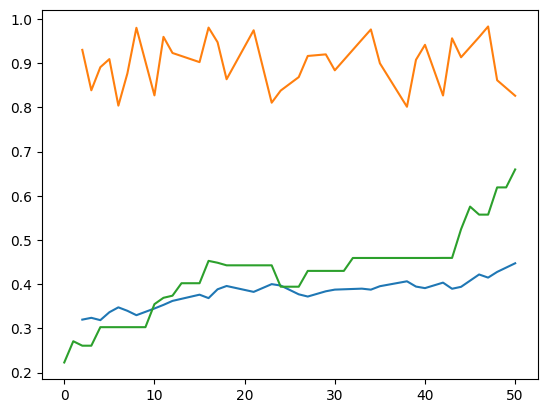

In [14]:
agent_idx = 0
job_id = 'task_0_0'
task_id = 'task_0'
plt.plot(*np.array(exp_log.agent_scores[job_id][agent_idx]).T)
plt.plot(*np.array(exp_log.agent_bids_normalized[job_id][agent_idx]).T)
plt.plot(np.array(exp_log.agent_reputation[task_id][agent_idx]))



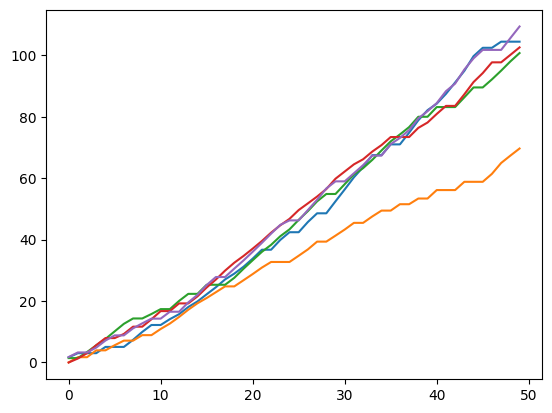

In [7]:
plt.plot(np.cumsum(exp_log.agent_reward_history.T, axis=0))

In [21]:
unemployed = []

2025-09-08 23:44:35.399 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.46it/s]
2025-09-08 23:45:10.504 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.46it/s]
2025-09-08 23:45:44.679 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.51it/s]
2025-09-08 23:46:19.788 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:21<00:00,  4.74it/s]
2025-09-08 23:46:52.752 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:21<00:00,  4.66it/s]
2025-09-08 23:47:26.386 | INFO     

Text(0.5, 0, 'unemployment')

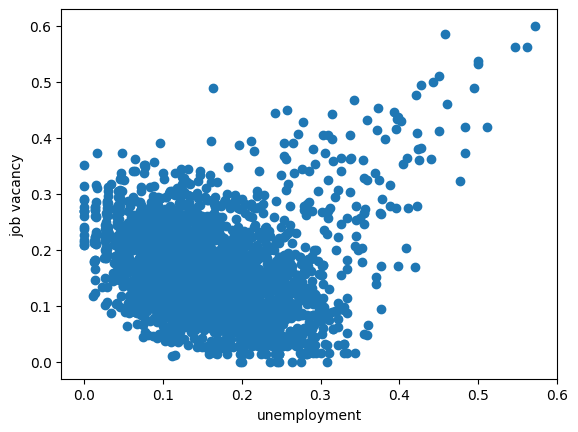

In [22]:
from tqdm import tqdm

n_tasks = 10
n_jobs = 10
n_agents = 100
market_limit = 1
market_pref_limit = 40
agent_pref_limit = 10
job_p = 0.7
train_p = 0.3
n_steps = 100
# for market_pref_limit in [5, 10]:
#     for agent_pref_limit in [3, 5]:

for job_p in [0.7, 0.75, 0.8, 0.85, 0.9]:
    for train_p in [0.1, 0.15, 0.2, 0.25, 0.3]:
        # pass

        task_ids = [f"task_{i}" for i in range(n_tasks)]
        tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

        jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=job_p, base_reward=10) for task_id in task_ids for i in range(n_jobs)]

        agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(n_agents)]

        for agent in agents:
            agent.set_policy(train_p=train_p)
        for agent in agents[:70]:
            task_preferences = [agent.task_ids[i] for i in np.random.permutation(agent.n_tasks)]
            agent.set_policy(task_preferences=task_preferences, train_p=train_p, underbid_factor=0.9)

        market = LabourMarket(jobs=jobs, market_pref_limit=market_pref_limit, agent_pref_limit=agent_pref_limit, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
        for _ in trange(n_steps):
            market.simulate_timestep()

        exp_log = market.export()

        for hx in exp_log.history:
            unemployed.append(((len(hx.unmatched_agents) - np.sum([a.action == 'train' for a in hx.agent_actions])) / (n_agents - np.sum([a.action == 'train' for a in hx.agent_actions])), len(hx.unmatched_jobs) / len(hx.base_prices)))

u = np.array(unemployed)
plt.scatter(u[:, 0], u[:, 1])
plt.ylabel('job vacancy')
plt.xlabel('unemployment')

Fitted parameters [a, b, c]: [ 0.0395626   0.11567441 -0.00052701]
R²: 0.4190
RMSE: 0.0423
Outliers removed: 50


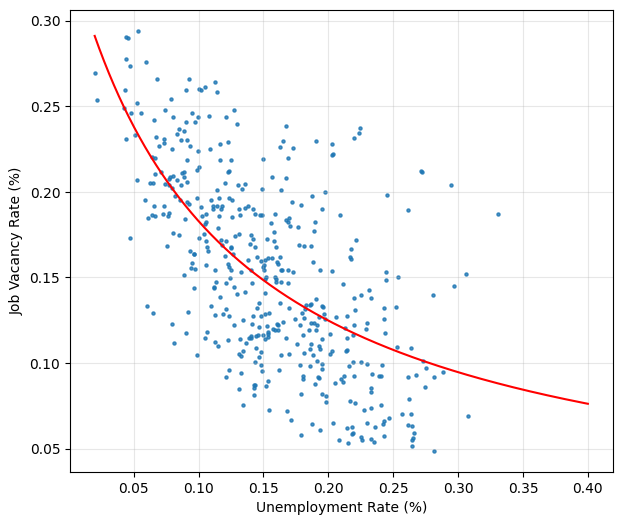

In [142]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import zscore
import matplotlib.pyplot as plt

def hyperbolic_func(x, a, b, c):
    """Hyperbolic function: y = a/(x + b) + c"""
    return a / (x + b) + c

def remove_outliers_residual_based(X, y, func, params, outlier_percent=5):
    """Remove outliers based on residuals from initial fit"""
    y_pred = func(X, *params)
    residuals = np.abs(y - y_pred)
    threshold = np.percentile(residuals, 100 - outlier_percent)
    mask = residuals <= threshold
    return X[mask], y[mask], mask

def remove_outliers_zscore(X, y, z_threshold=2.5):
    """Remove outliers based on Z-score"""
    z_scores_x = np.abs(zscore(X))
    z_scores_y = np.abs(zscore(y))
    mask = (z_scores_x < z_threshold) & (z_scores_y < z_threshold)
    return X[mask], y[mask], mask

def fit_hyperbola_with_outlier_removal(data, outlier_percent=5, method='residual'):
    """
    Fit hyperbolic curve with outlier removal
    
    Parameters:
    - data: numpy array of shape (n, 2) or tuple (X, y)
    - outlier_percent: percentage of outliers to remove
    - method: 'residual' or 'zscore'
    """
    
    # Handle input format
    if isinstance(data, tuple):
        X, y = data
    else:
        X, y = data[:, 0], data[:, 1]
    
    # Initial fit to identify outliers (if using residual method)
    if method == 'residual':
        # Robust initial parameter estimation
        try:
            initial_params = [np.std(y) * np.mean(X), np.mean(X), np.mean(y)]
            popt_initial, _ = curve_fit(hyperbolic_func, X, y, p0=initial_params, maxfev=5000)
        except:
            # Fallback parameters
            popt_initial = [1.0, 1.0, np.mean(y)]
        
        X_clean, y_clean, mask = remove_outliers_residual_based(
            X, y, hyperbolic_func, popt_initial, outlier_percent
        )
    else:  # zscore method
        z_threshold = np.sqrt(2 * np.log(100/outlier_percent))  # Convert percentage to z-score
        X_clean, y_clean, mask = remove_outliers_zscore(X, y, z_threshold)
    
    # Final fit on cleaned data
    try:
        initial_params = [np.std(y_clean) * np.mean(X_clean), np.mean(X_clean), np.mean(y_clean)]
        popt_final, pcov = curve_fit(hyperbolic_func, X_clean, y_clean, p0=initial_params, maxfev=5000)
    except Exception as e:
        raise RuntimeError(f"Curve fitting failed: {e}")
    
    # Calculate fit quality metrics
    y_pred = hyperbolic_func(X_clean, *popt_final)
    r_squared = 1 - np.sum((y_clean - y_pred)**2) / np.sum((y_clean - np.mean(y_clean))**2)
    rmse = np.sqrt(np.mean((y_clean - y_pred)**2))
    
    results = {
        'params': popt_final,
        'covariance': pcov,
        'X_clean': X_clean,
        'y_clean': y_clean,
        'outlier_mask': mask,
        'r_squared': r_squared,
        'rmse': rmse,
        'outliers_removed': len(X) - len(X_clean)
    }
    
    return results

# Fit with outlier removal
results = fit_hyperbola_with_outlier_removal(
    u, 
    outlier_percent=10, 
    method='residual'
)

print(f"Fitted parameters [a, b, c]: {results['params']}")
print(f"R²: {results['r_squared']:.4f}")
print(f"RMSE: {results['rmse']:.4f}")
print(f"Outliers removed: {results['outliers_removed']}")

# Plot results
X = u[:,0]
y = u[:,1]
plt.figure(figsize=(7, 6))
# plt.scatter(X, y, alpha=0.6, label='Original data')
plt.scatter(results['X_clean'], results['y_clean'], color='tab:blue', alpha=0.8, s=5, label='data')

X_plot = np.linspace(np.min(X), 0.4, 1000)
y_plot = hyperbolic_func(X_plot, *results['params'])
plt.plot(X_plot, y_plot, 'r-', label=f'Fitted curve: y = {results["params"][0]:.2f}/(x + {results["params"][1]:.2f}) + {results["params"][2]:.2f}')

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Job Vacancy Rate (%)')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [107]:
unemployed

[(np.float64(0.4222222222222222), 0.2777777777777778),
 (np.float64(0.37777777777777777), 0.2911392405063291),
 (np.float64(0.35555555555555557), 0.24675324675324675),
 (np.float64(0.41935483870967744), 0.16923076923076924),
 (np.float64(0.29411764705882354), 0.2),
 (np.float64(0.3023255813953488), 0.15492957746478872),
 (np.float64(0.3333333333333333), 0.08823529411764706),
 (np.float64(0.29347826086956524), 0.04411764705882353),
 (np.float64(0.2872340425531915), 0.0821917808219178),
 (np.float64(0.22727272727272727), 0.10526315789473684),
 (np.float64(0.26373626373626374), 0.04285714285714286),
 (np.float64(0.32967032967032966), 0.031746031746031744),
 (np.float64(0.2696629213483146), 0.09722222222222222),
 (np.float64(0.25842696629213485), 0.043478260869565216),
 (np.float64(0.28421052631578947), 0.02857142857142857),
 (np.float64(0.2608695652173913), 0.05555555555555555),
 (np.float64(0.26881720430107525), 0.02857142857142857),
 (np.float64(0.2857142857142857), 0.07142857142857142)

In [126]:
u = np.array(unemployed)


In [137]:
u = np.array(unemployed).reshape(500, 5, 2).mean(axis=1)

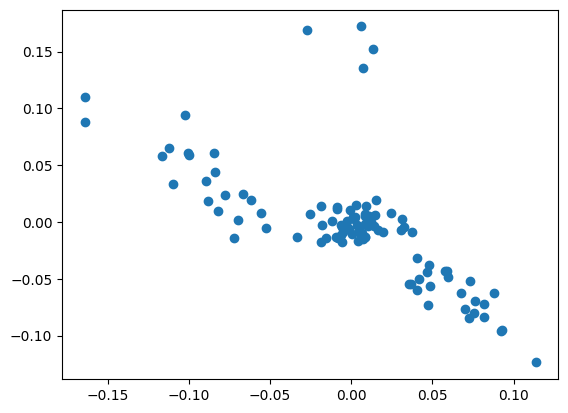

In [124]:
u = np.array(unemployed)
u[:, 1] = 1 - u[:, 1]
u2 = u.reshape(100, 25, 2).mean(axis=1)
u2_diff = np.diff(u2, axis=0)

unemployed_rate = u2_diff[:, 0]
gdp = u2_diff[:, 1]
plt.scatter(gdp, unemployed_rate)


In [94]:
u = np.array(unemployed)
u[:, 1] = 1 - u[:, 1]
u_diff = np.diff(u, axis=0)

In [121]:
import numpy as np
from scipy import stats
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def remove_outliers_residual_based(X, y, slope, intercept, outlier_percent=5):
    """Remove outliers based on residuals from initial linear fit"""
    y_pred = slope * X + intercept
    residuals = np.abs(y - y_pred)
    threshold = np.percentile(residuals, 100 - outlier_percent)
    mask = residuals <= threshold
    return X[mask], y[mask], mask

def remove_outliers_zscore(X, y, z_threshold=2.5):
    """Remove outliers based on Z-score"""
    z_scores_x = np.abs(zscore(X))
    z_scores_y = np.abs(zscore(y))
    mask = (z_scores_x < z_threshold) & (z_scores_y < z_threshold)
    return X[mask], y[mask], mask

def remove_outliers_cook_distance(X, y, threshold=4):
    """Remove outliers based on Cook's distance"""
    from sklearn.linear_model import LinearRegression
    
    X_reshaped = X.reshape(-1, 1) if X.ndim == 1 else X
    model = LinearRegression().fit(X_reshaped, y)
    y_pred = model.predict(X_reshaped)
    
    # Calculate leverage (hat values)
    H = X_reshaped @ np.linalg.inv(X_reshaped.T @ X_reshaped) @ X_reshaped.T
    h = np.diag(H)
    
    # Calculate Cook's distance
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    p = X_reshaped.shape[1] + 1  # number of parameters
    n = len(y)
    
    cook_d = (residuals**2 / (p * mse)) * (h / (1 - h)**2)
    
    # Remove points with Cook's distance > threshold/n
    mask = cook_d <= threshold / n
    return X[mask], y[mask], mask

def linear_regression_with_outlier_removal(data, outlier_percent=5, method='residual', robust_method=None):
    """
    Perform linear regression with outlier removal
    
    Parameters:
    - data: numpy array of shape (n, 2) or tuple (X, y)
    - outlier_percent: percentage of outliers to remove
    - method: 'residual', 'zscore', or 'cook'
    - robust_method: None, 'huber', or 'theil_sen' for robust regression
    """
    
    # Handle input format
    if isinstance(data, tuple):
        X, y = data
    else:
        X, y = data[:, 0], data[:, 1]
    
    X = np.asarray(X)
    y = np.asarray(y)
    
    # Initial fit for outlier detection
    if method == 'residual':
        slope_init, intercept_init, r_init, p_value_init, std_err_init = stats.linregress(X, y)
        X_clean, y_clean, mask = remove_outliers_residual_based(
            X, y, slope_init, intercept_init, outlier_percent
        )
    elif method == 'zscore':
        z_threshold = np.sqrt(2 * np.log(100/outlier_percent))
        X_clean, y_clean, mask = remove_outliers_zscore(X, y, z_threshold)
    elif method == 'cook':
        X_clean, y_clean, mask = remove_outliers_cook_distance(X, y)
    else:
        raise ValueError("Method must be 'residual', 'zscore', or 'cook'")
    
    # Final regression on cleaned data
    if robust_method == 'huber':
        # Huber regression (robust to outliers)
        X_reshaped = X_clean.reshape(-1, 1)
        huber = HuberRegressor(epsilon=1.35, max_iter=100)
        huber.fit(X_reshaped, y_clean)
        slope = huber.coef_[0]
        intercept = huber.intercept_
        
        # Calculate stats manually for robust regression
        y_pred = slope * X_clean + intercept
        r_value = np.corrcoef(y_clean, y_pred)[0, 1]
        r_squared = r2_score(y_clean, y_pred)
        
        # Standard error approximation for robust regression
        residuals = y_clean - y_pred
        mse = np.mean(residuals**2)
        x_var = np.var(X_clean)
        slope_std_err = np.sqrt(mse / (len(X_clean) * x_var))
        intercept_std_err = np.sqrt(mse * (1/len(X_clean) + np.mean(X_clean)**2/(len(X_clean) * x_var)))
        
        # P-value approximation (less reliable for robust regression)
        t_stat_slope = slope / slope_std_err
        p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat_slope), len(X_clean) - 2))
        
    elif robust_method == 'theil_sen':
        # Theil-Sen estimator
        slope, intercept, low_slope, high_slope = stats.theilslopes(y_clean, X_clean)
        y_pred = slope * X_clean + intercept
        r_value = np.corrcoef(y_clean, y_pred)[0, 1]
        r_squared = r2_score(y_clean, y_pred)
        
        # Standard errors not directly available for Theil-Sen
        slope_std_err = (high_slope - low_slope) / (2 * 1.96)  # Approximation
        intercept_std_err = np.nan  # Not easily computed
        p_value = np.nan  # Not easily computed
        
    else:
        # Standard least squares regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(X_clean, y_clean)
        slope_std_err = std_err
        
        # Calculate intercept standard error
        x_mean = np.mean(X_clean)
        x_var = np.var(X_clean)
        intercept_std_err = std_err * np.sqrt((1/len(X_clean)) + (x_mean**2)/(len(X_clean) * x_var))
    
    # Additional metrics
    y_pred_clean = slope * X_clean + intercept
    rmse = np.sqrt(np.mean((y_clean - y_pred_clean)**2))
    mae = np.mean(np.abs(y_clean - y_pred_clean))
    
    # Confidence intervals (95%)
    t_critical = stats.t.ppf(0.975, len(X_clean) - 2)
    slope_ci = [slope - t_critical * slope_std_err, slope + t_critical * slope_std_err]
    intercept_ci = [intercept - t_critical * intercept_std_err, intercept + t_critical * intercept_std_err]
    
    results = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,  # Correlation coefficient
        'r_squared': r_value**2 if not robust_method else r_squared,  # Coefficient of determination
        'p_value': p_value,
        'slope_std_err': slope_std_err,
        'intercept_std_err': intercept_std_err,
        'slope_ci': slope_ci,
        'intercept_ci': intercept_ci,
        'rmse': rmse,
        'mae': mae,
        'X_clean': X_clean,
        'y_clean': y_clean,
        'outlier_mask': mask,
        'outliers_removed': len(X) - len(X_clean),
        'n_samples': len(X_clean)
    }
    
    return results

def plot_regression_results(X_orig, y_orig, results, title="Linear Regression with Outlier Removal"):
    """Plot the regression results"""
    plt.figure(figsize=(12, 8))
    
    # # Original data
    # outlier_mask = ~results['outlier_mask']
    # if np.any(outlier_mask):
    #     plt.scatter(X_orig[outlier_mask], y_orig[outlier_mask], 
    #                color='red', alpha=0.6, s=50, label='Outliers (removed)', marker='x')
    
    # Clean data
    plt.scatter(results['X_clean'], results['y_clean'], 
               color='blue', alpha=0.7, s=30)
    
    # Regression line
    X_line = np.linspace(np.min(X_orig), np.max(X_orig), 100)
    y_line = results['slope'] * X_line + results['intercept']
    plt.plot(X_line, y_line, 'r-', linewidth=2, 
             label=f'y = {results["slope"]:.3f}x + {results["intercept"]:.3f}')
    
    # Confidence interval for the line
    y_pred_clean = results['slope'] * results['X_clean'] + results['intercept']
    residuals = results['y_clean'] - y_pred_clean
    mse = np.mean(residuals**2)
    x_mean = np.mean(results['X_clean'])
    x_var = np.var(results['X_clean'])
    
    # Standard error of prediction
    se_line = np.sqrt(mse * (1/len(results['X_clean']) + 
                             (X_line - x_mean)**2/(len(results['X_clean']) * x_var)))
    t_critical = stats.t.ppf(0.975, len(results['X_clean']) - 2)
    y_ci_lower = y_line - t_critical * se_line
    y_ci_upper = y_line + t_critical * se_line
    
    plt.fill_between(X_line, y_ci_lower, y_ci_upper, alpha=0.2, color='red', 
                     label='95% Confidence Interval')
    
    plt.xlabel('Change in unemployment rate')
    plt.ylabel('Change in GDP Growth')
    plt.title("")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f'R = {results["r_value"]:.4f}\n'
    stats_text += f'R² = {results["r_squared"]:.4f}\n'
    stats_text += f'RMSE = {results["rmse"]:.4f}\n'
    stats_text += f'p-value = {results["p_value"]:.2e}\n' if not np.isnan(results["p_value"]) else 'p-value = N/A\n'
    stats_text += f'n = {results["n_samples"]}\n'
    # stats_text += f'Outliers removed = {results["outliers_removed"]}'
    
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()



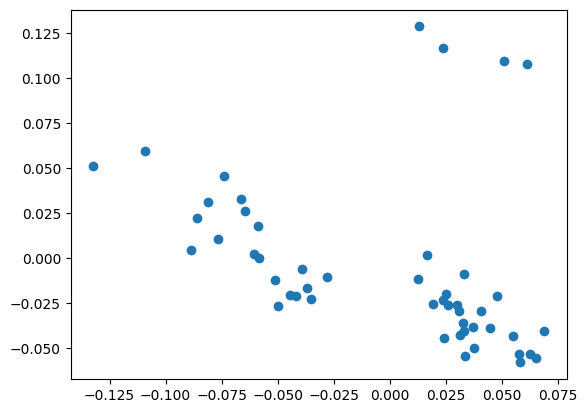

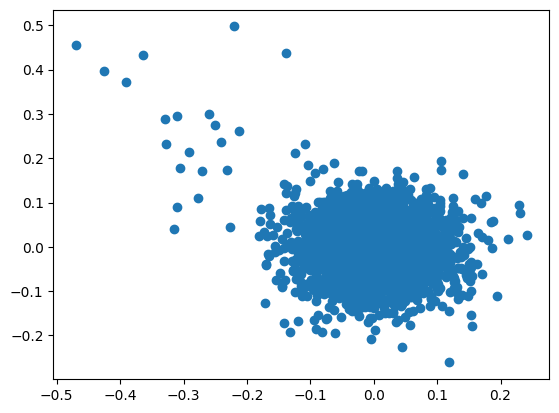

In [106]:
unemployed_rate = u_diff[:, 0]
gdp = u_diff[:, 1]
plt.scatter(gdp, unemployed_rate)


In [105]:
unemployed_rate

array([-0.04444444, -0.02222222,  0.06379928, ..., -0.01136364,
       -0.01581028,  0.0994313 ], shape=(2499,))


=== Method: residual + huber ===
Slope: -0.6472 ± 0.0529
Intercept: -0.0092 ± 0.0030
R-value: 0.7730
R²: 0.5952
RMSE: 0.0295
p-value: 0.00e+00
Outliers removed: 2


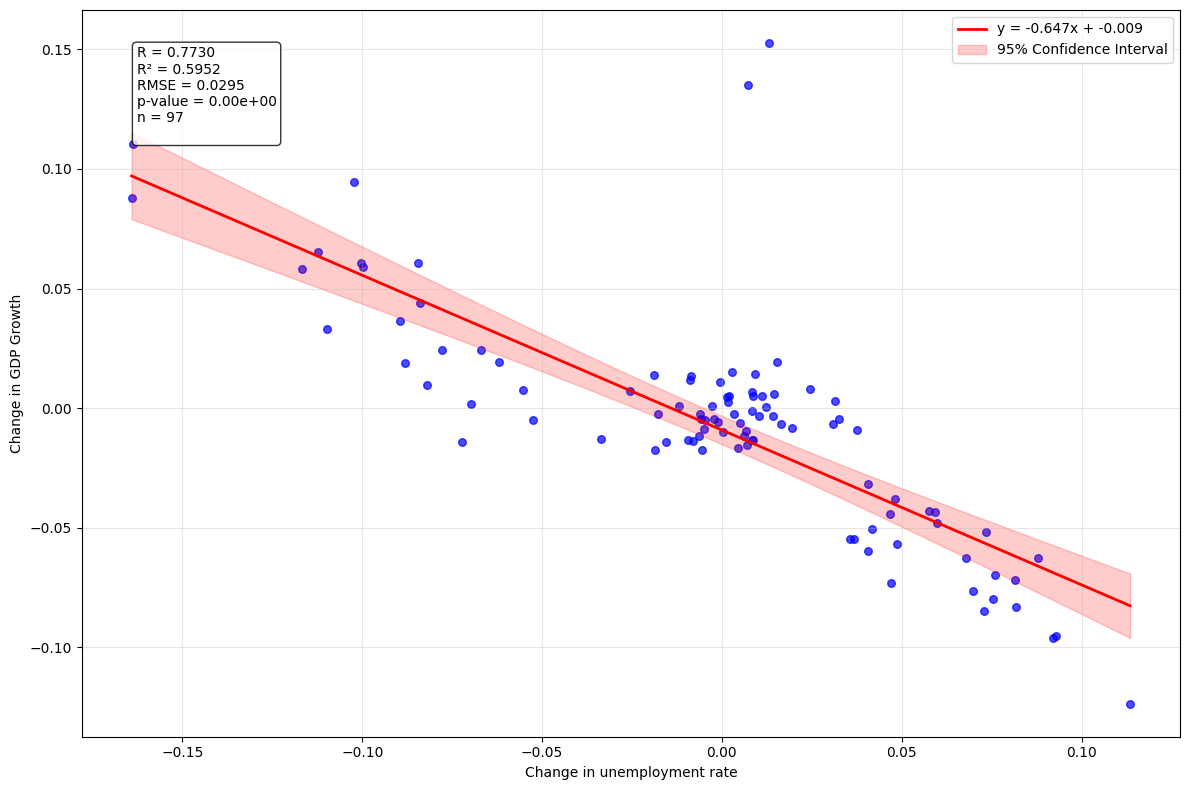

In [122]:

# Generate sample data with outliers
np.random.seed(42)

X_true = gdp
y_true = unemployed_rate

# Different methods comparison
methods = ['residual', 'zscore', 'cook']
robust_methods = [None, 'huber']

method = 'residual'
robust = 'huber'
method_name = f"{method}" + (f" + {robust}" if robust else "")
print(f"\n=== Method: {method_name} ===")

results = linear_regression_with_outlier_removal(
    (X_true, y_true), 
    outlier_percent=0.5, 
    method='zscore',
    robust_method=robust
)

print(f"Slope: {results['slope']:.4f} ± {results['slope_std_err']:.4f}")
print(f"Intercept: {results['intercept']:.4f} ± {results['intercept_std_err']:.4f}")
print(f"R-value: {results['r_value']:.4f}")
print(f"R²: {results['r_squared']:.4f}")
print(f"RMSE: {results['rmse']:.4f}")
print(f"p-value: {results['p_value']:.2e}" if not np.isnan(results['p_value']) else "p-value: N/A")
print(f"Outliers removed: {results['outliers_removed']}")

plot_regression_results(X_true, y_true, results, f"Linear Regression - {method_name}")


In [178]:
def gini(wealth):
    wealth = np.sort(wealth[wealth >= 0])
    n = len(wealth)
    cumsum = np.cumsum(wealth)
    return 1 - (2 * np.sum(cumsum)) / (n * cumsum[-1]) + 1/n

all_g = []

for market_limit in trange(10):

    task_ids = [f"task_{i}" for i in range(10)]
    tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

    jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(5)]

    agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(50)]
    for agent in agents:
        agent.set_policy(train_p=0.2, underbid_factor=0.9)

    # agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
    # agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
    # agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
    # agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

    market = LabourMarket(jobs=jobs, agent_pref_limit=50, market_pref_limit=50, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
    for _ in trange(100):
        market.simulate_timestep()

    exp_log = market.export()

    e = [gini(np.array(r)) for r in exp_log.agent_total_rewards]
    all_g.append([np.mean(e), np.std(e)])


100%|██████████| 100/100 [00:02<00:00, 36.65it/s]
/tmp/ipykernel_2356013/193962131.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (2 * np.sum(cumsum)) / (n * cumsum[-1]) + 1/n
100%|██████████| 10/10 [01:13<00:00,  7.34s/it]


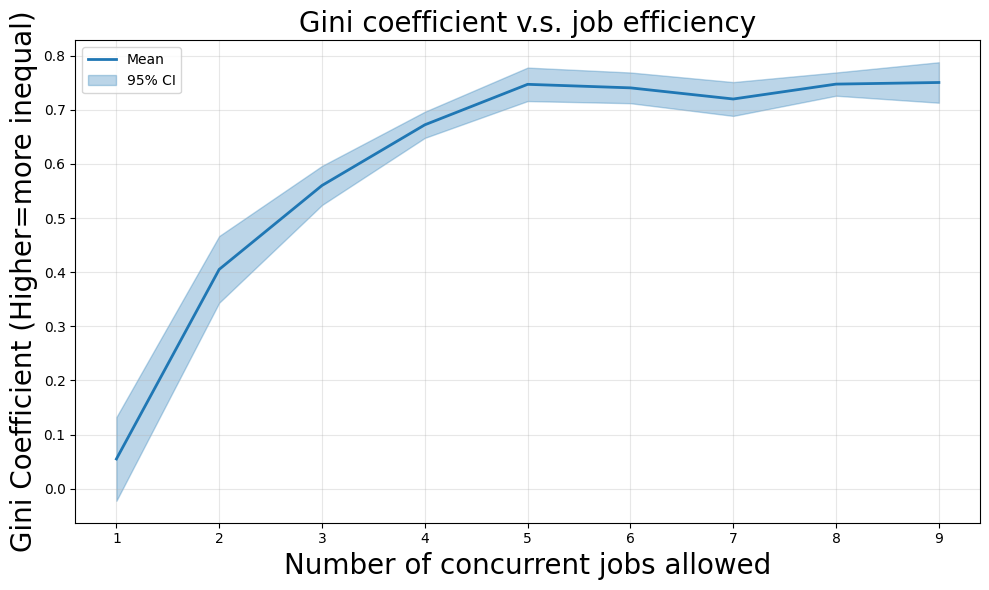

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confidence_interval(means, stds, title="Time Series with 95% Confidence Interval"):
    """
    Plot mean with 95% confidence interval using fill_between.
    
    Args:
        means: array of mean values (length 20)
        stds: array of standard deviation values (length 20)
    """
    time_steps = np.arange(len(means))
    
    # Calculate 95% confidence interval (1.96 * std for normal distribution)
    ci_multiplier = 1.96
    upper_bound = means + ci_multiplier * stds
    lower_bound = means - ci_multiplier * stds
    
    plt.figure(figsize=(10, 6))
    
    # Plot the mean line
    plt.plot(time_steps, means, '-', linewidth=2, label='Mean')
    
    # Fill the confidence interval
    plt.fill_between(time_steps, lower_bound, upper_bound, 
                     alpha=0.3, color='tab:blue', label='95% CI')
    
    plt.xlabel('Number of concurrent jobs allowed', fontsize=20)
    plt.ylabel('Gini Coefficient (Higher=more inequal)', fontsize=20)
    plt.title(title, fontsize=20)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

all_g = np.array(all_g)
plot_confidence_interval(all_g[:, 0], all_g[:, 1], title="Gini coefficient v.s. Job efficiency")

In [205]:
market_limit = 5

task_ids = [f"task_{i}" for i in range(10)]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(5)]

agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(50)]
for agent in agents:
    agent.set_policy(train_p=0.2, underbid_factor=0.95)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

market = LabourMarket(jobs=jobs, agent_pref_limit=50, market_pref_limit=50, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(100):
    for agent in agents:
        agent.set_policy(train_p=0.2, underbid_factor=np.clip((agent.underbid_factor * 0.99 + np.random.normal(0, 0.05)), 0, 1))
    market.simulate_timestep()

2025-09-09 05:07:13.903 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 50 agents and 50 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:06<00:00, 14.41it/s]


In [206]:
exp_log = market.export()

In [227]:
# agent bids interpolate
from scipy import interpolate
all_lines = []

for i in range(50):
    c = np.array(exp_log.agent_bids['task_1_2'][i])
    linear_interp = interpolate.interp1d(c[:, 0], c[:, 1], kind='linear')
    all_lines.append(linear_interp(np.arange(5, 95)))


Text(0.5, 1.0, 'Agent bid as % of client budget over time')

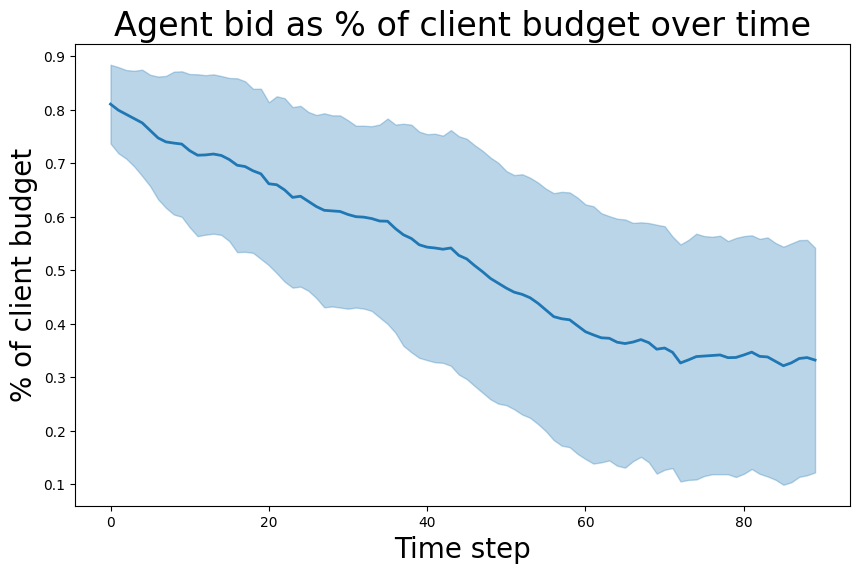

In [238]:
l = np.array(all_lines)

means = l.mean(axis=0) / 10
stds = l.std(axis=0) / 10
time_steps = np.arange(len(means))
ci_multiplier = 1
upper_bound = means + ci_multiplier * stds
lower_bound = means - ci_multiplier * stds

plt.figure(figsize=(10, 6))

# Plot the mean line
plt.plot(time_steps, means, '-', linewidth=2, label='Mean')

# Fill the confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, 
                    alpha=0.3, color='tab:blue', label='95% CI')

plt.xlabel("Time step", fontsize=20)
plt.ylabel("% of client budget", fontsize=20)
plt.title("Agent bid as % of client budget over time", fontsize=24)

In [218]:
for i in range(50):
    c = np.array(exp_log.agent_bids['task_1_2']).mean(axis=-1)
    plt.plot(c[:, 0], c[:, 1])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (50,) + inhomogeneous part.

In [10]:
# %%
from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.agents.ssa import LLMSSA
from ssa.agents.policy import PolicyAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model, init_openrouter_chat_model
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13123)
# model = init_azure_model()

task_ids = ["task_a", "task_b", "task_c", "task_d"]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, base_reward=7 + i) for task_id in task_ids for i in range(4)]

# agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(4)]
# for agent in agents:
#     agent.set_policy(underbid_factor=0.9)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# # agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# # agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

agents = []
model = init_openrouter_chat_model(model_name='openai/gpt-oss-120b', temperature=0.5)
agents.append(LLMAgent(agent_id=f"llm_0", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_1", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_2", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_3", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_4", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_", jobs=jobs, model=model, verbose=False))
agents.append(LLMSSA(agent_id=f"ssa_0", jobs=jobs, model=model, verbose=True))


market = LabourMarket(jobs=jobs, market_limit=3, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=20, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(50):
    market.simulate_timestep()

hx = market.get_job_performance(task_id='task_a', filter_initial=True)

exp_log = market.export('logs/ssa_test_4.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


2025-09-08 21:37:03.646 | INFO     | ssa.market:__init__:112 - Set up LabourMarket with 7 agents and 4 tasks. Initializing...
  0%|          | 0/50 [00:00<?, ?it/s]2025-09-08 21:37:03.668 | INFO     | ssa.agents.llm:get_agent_action:161 - === ROUND 1 ===

RECENT MARKET ACTIVITY (Last 10 rounds):
This is Round 1. No history recorded yet.

PREVIOUS REASONING
(First Turn - No reasoning trace yet)

YOUR RECENT ACTIONS:

>> REPUTATION - task_c: 0.26 | task_b: 0.25 | task_d: 0.27 | task_a: 0.25

THIS ROUND'S LISTINGS (task_id: job_id@client_budget, grouped by task types):
task_a: task_a_0@7.0, task_a_1@8.0, task_a_2@9.0, task_a_3@10.0
task_b: task_b_0@7.0, task_b_1@8.0, task_b_2@9.0, task_b_3@10.0
task_c: task_c_0@7.0, task_c_1@8.0, task_c_2@9.0, task_c_3@10.0
task_d: task_d_0@7.0, task_d_1@8.0, task_d_2@9.0, task_d_3@10.0

  0%|          | 0/50 [00:05<?, ?it/s]


KeyboardInterrupt: 

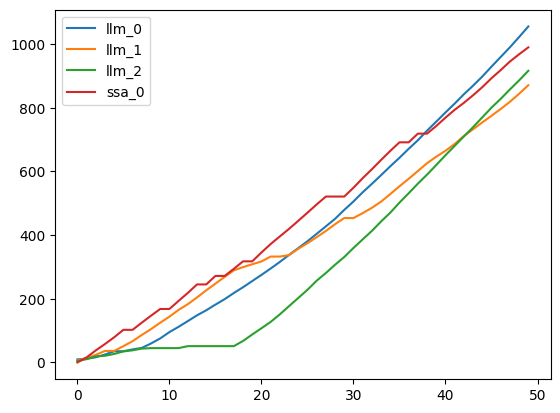

In [4]:
exp_log = market.export('logs/ssa_test_2.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


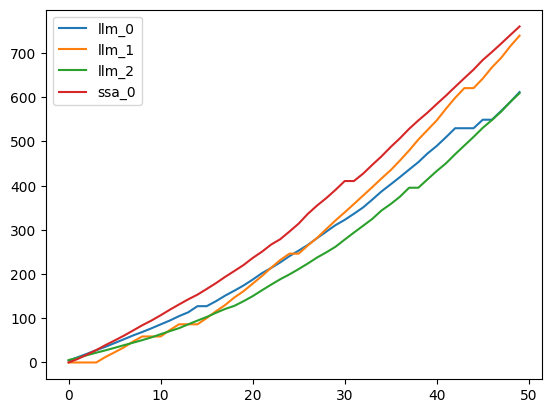

In [16]:

exp_log = market.export('logs/ssa_test_1.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()

In [3]:
for agent in market.agents:
    agent.token_usage = [t for t in agent.token_usage if t]


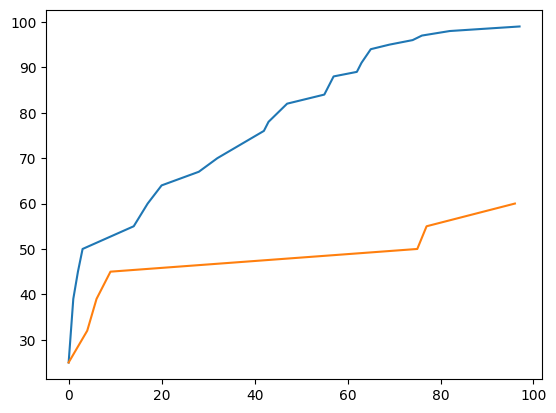

In [21]:
x, y = exp_log.agents[-1].skill_history['task_a']
plt.plot(x, y)
x, y = exp_log.agents[0].skill_history['task_a']
plt.plot(x, y)

In [ ]:
# exp_log = market.export('logs/llm_baseline_1.log')

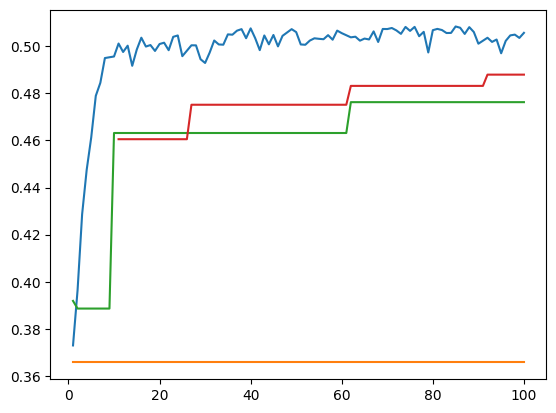

In [2]:
for agent_trace in exp_log.agent_scores['task_a_1']:
    agent_trace = np.array(agent_trace)
    plt.plot(agent_trace[:, 0], agent_trace[:, 1])

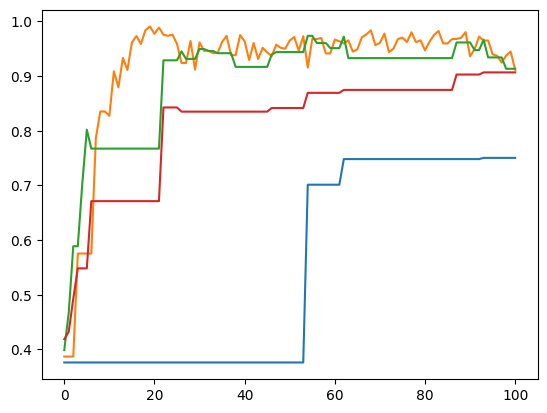

In [ ]:
plt.plot(np.array(exp_log.agent_reputation['task_c']).T)

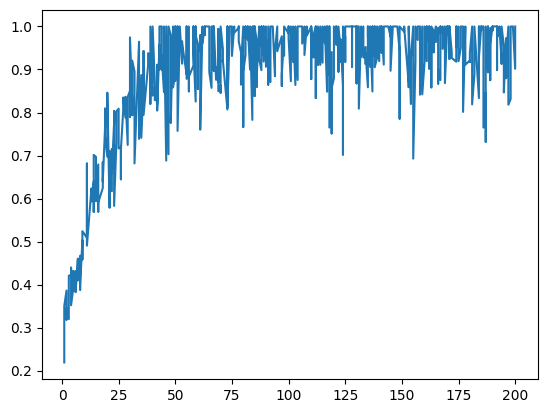

In [42]:
hx = market.get_job_performance(task_id='task_a', agent_idx=0, filter_initial=True)

import matplotlib.pyplot as plt

plt.plot([p.round for p in hx], [p.performance for p in hx], label='performance')

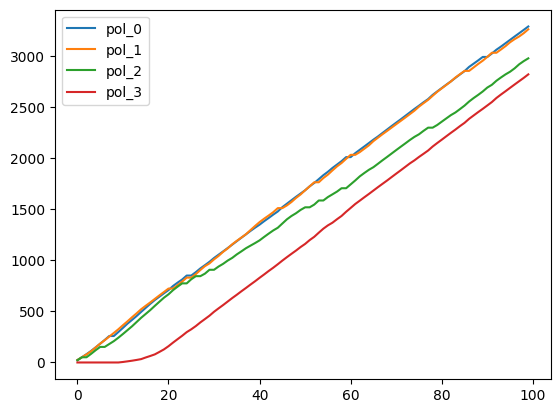

In [4]:
import matplotlib.pyplot as plt

# plt.plot([p.round for p in hx], [p.performance for p in hx])
# plt.plot([p.round for p in hx], [p.reputation for p in hx])

exp_log = market.export()
rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


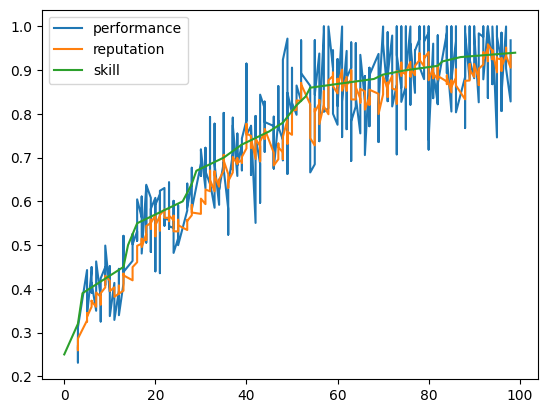

In [36]:
task_id = 'task_c'
hx = market.get_job_performance(task_id=task_id, agent_idx=0, filter_initial=True)

import matplotlib.pyplot as plt

plt.plot([p.round for p in hx], [p.performance for p in hx], label='performance')
plt.plot([p.round for p in hx], [p.reputation for p in hx], label='reputation')
X, y = market.agents[0].get_skill_history(task_id)
plt.plot(X, np.array(y)/100, label='skill')
plt.legend()

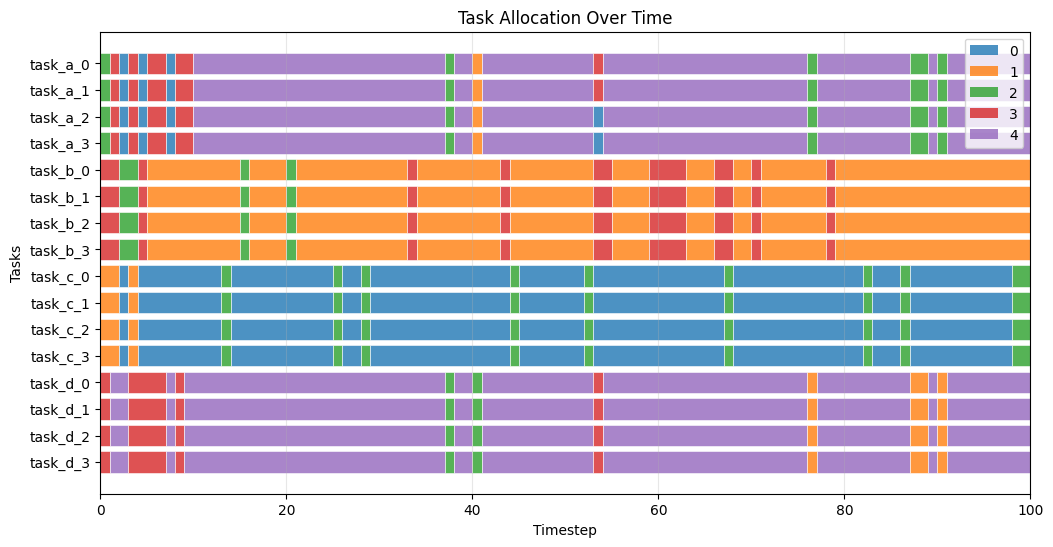

In [37]:
from ssa.plotting import plot_allocation
allocations = [history.matched_jobs for history in exp_log.history]

fig, ax = plt.subplots(figsize=(12, 6))
ax = plot_allocation(ax, allocation=allocations)